pancreas dropout CBDir指标绘制

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [19]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'
data = 'dropout_pancreas'
save_dir = f'../figures_new/{data}'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [7]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/pancreas.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('Ductal', 'Ngn3 low EP'),
 ('Ngn3 low EP', 'Ngn3 high EP'),
 ('Ngn3 high EP', 'Pre-endocrine'),
 ('Pre-endocrine', 'Alpha'),
 ('Pre-endocrine', 'Beta'),
 ('Pre-endocrine', 'Delta'),
 ('Pre-endocrine', 'Epsilon')]

In [8]:
models_order = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'latentvelo(lt)', 'velovi', 'stt', 'stt(vj)', 'velovgi']

In [9]:
metric_name = 'cbdir'
basis = 'umap'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results_orig = {}
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    metrics = []
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        idx_name = f'{metric_name}_{model_name}_velocity_{basis}_{edge}' if model in ['latentvelo', 'velovgi'] else f'{metric_name}_{model_name}_velocity_{edge}'
        idx_vj = f'{metric_name}_vj_{edge}'
        idx_lt = f'{metric_name}_spliced_velocity_{basis}_{edge}'
        file_name = 'metric' if model in ['latentvelo', 'velovgi'] else f'metric_{basis}'
        for rate in np.arange(0.05, 0.45, 0.05):
            rate_dir = f'{base_dir}/{data}/{model}/{rate:.2f}'
            for subdir in os.listdir(rate_dir):
                metric_path = f'{rate_dir}/{subdir}/{file_name}.csv'
                if os.path.exists(metric_path):
                    metric_df = pd.read_csv(metric_path, index_col=0)
                    value = float(metric_df.loc[idx_name, '0'])
                    metrics.append((model, rate, value))
                    if model == 'stt':
                        value_vj = float(metric_df.loc[idx_vj, '0'])
                        metrics.append(('stt(vj)', rate, value_vj))
                    elif model == 'latentvelo':
                        value_lt = float(metric_df.loc[idx_lt, '0'])
                        metrics.append(('latentvelo(lt)', rate, value_lt))
    df = pd.DataFrame(metrics, columns=['model', 'rate', metric_name])
    df_result = df.groupby(['model', 'rate'])[metric_name].agg(['mean', 'std'])
    df_result.reset_index(inplace=True)
    df_result['model'] = pd.Categorical(df_result['model'], 
                                        categories=models_order, 
                                        ordered=True)
    df_result.sort_values(['model', 'rate'], inplace=True)
    df_result.set_index(['model', 'rate'], inplace=True)
    df_result['size'] = 1.5 - df_result['std']
    results_orig[edge] = df
    results[edge] = df_result
results['Ductal -> Ngn3 low EP']

mean       std      size
model   rate                              
scvelo  0.05  0.062917  0.085653  1.414347
        0.10  0.013065  0.030783  1.469217
        0.15  0.048389  0.093276  1.406724
        0.20 -0.006296  0.068772  1.431228
        0.25 -0.009346  0.133927  1.366073
...                ...       ...       ...
velovgi 0.20 -0.082545  0.082257  1.417743
        0.25 -0.094593  0.084226  1.415774
        0.30 -0.097796  0.097464  1.402536
        0.35 -0.004553  0.053013  1.446987
        0.40 -0.061861  0.075677  1.424323

[80 rows x 3 columns]

In [10]:
import numpy as np
import scanpy as sc
import os
adata_path = '/HDD1/xueweizhi/velocity_benchmark_data/pancreas/endocrinogenesis_day15.h5ad'
base_dir = os.path.dirname(adata_path)
rates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
repeats = 3

In [11]:
import scipy.sparse as sp
def calculate_sparsity_safe(matrix):
    """
    高效计算稀疏度，自动处理稀疏矩阵和稠密矩阵，避免内存溢出
    """
    # 获取总元素个数 (行 * 列)
    total_elements = matrix.shape[0] * matrix.shape[1]
    
    # 获取非零元素个数
    if sp.issparse(matrix):
        nnz = matrix.nnz
    else:
        nnz = np.count_nonzero(matrix)
        
    # 稀疏度 = 1 - (非零占比)
    return 1.0 - (nnz / total_elements)

In [12]:
# 存储每个dropout rate的平均稀疏度
avg_sparsities = []

# 对于每个dropout rate
for rate in rates:
    sparsities_u = []
    sparsities_s = []
    
    # 这里的 save_dir 定义需确保正确
    save_dir = os.path.join(base_dir, f"{rate:.2f}")
    
    for i in range(repeats):
        file_path = os.path.join(save_dir, f"{i}.h5ad")
        
        # 读取数据 (推荐使用 backed='r' 模式如果是超大数据集，但普通大小直接读即可)
        adata_i = sc.read_h5ad(file_path)
        
        # --- 修改点开始 ---
        # 直接传入矩阵，不要调用 .A 或 .toarray()
        u_sparsity = calculate_sparsity_safe(adata_i.layers['unspliced'])
        s_sparsity = calculate_sparsity_safe(adata_i.layers['spliced'])
        # --- 修改点结束 ---
        
        sparsities_u.append(u_sparsity)
        sparsities_s.append(s_sparsity)
    
    # 计算平均值
    avg_sparsity_u = np.mean(sparsities_u)
    avg_sparsity_s = np.mean(sparsities_s)
    
    # 联合稀疏度
    # 数学上：因为 unspliced 和 spliced 矩阵形状完全相同 (Cells x Genes)
    # 所以 (Sparsity_U + Sparsity_S) / 2 等同于 (Total_Zeros_U + Total_Zeros_S) / Total_Elements_Combined
    avg_sparsity_combined = (avg_sparsity_u + avg_sparsity_s) / 2
    
    avg_sparsities.append({
        'rate': rate,
        'avg_sparsity_u': avg_sparsity_u,
        'avg_sparsity_s': avg_sparsity_s,
        'avg_sparsity_combined': avg_sparsity_combined
    })

# 查看结果
avg_sparsities

[{'rate': 0.05,
  'avg_sparsity_u': 0.9713179465148357,
  'avg_sparsity_s': 0.9143400729406873,
  'avg_sparsity_combined': 0.9428290097277615},
 {'rate': 0.1,
  'avg_sparsity_u': 0.9731110489803075,
  'avg_sparsity_s': 0.9185583125552051,
  'avg_sparsity_combined': 0.9458346807677563},
 {'rate': 0.15,
  'avg_sparsity_u': 0.9748821569866823,
  'avg_sparsity_s': 0.9228068638071137,
  'avg_sparsity_combined': 0.9488445103968981},
 {'rate': 0.2,
  'avg_sparsity_u': 0.9766275468088992,
  'avg_sparsity_s': 0.9270761500228785,
  'avg_sparsity_combined': 0.9518518484158889},
 {'rate': 0.25,
  'avg_sparsity_u': 0.978353854150786,
  'avg_sparsity_s': 0.9313663838027186,
  'avg_sparsity_combined': 0.9548601189767523},
 {'rate': 0.3,
  'avg_sparsity_u': 0.9800451501019399,
  'avg_sparsity_s': 0.9356936776663186,
  'avg_sparsity_combined': 0.9578694138841293},
 {'rate': 0.35,
  'avg_sparsity_u': 0.9817173603515484,
  'avg_sparsity_s': 0.9400374770378878,
  'avg_sparsity_combined': 0.960877418694718

In [16]:
rate_label_map = {}

for item in avg_sparsities:
    r = item['rate']
    # 将稀疏度转换为百分比并保留1位小数
    u_pct = item['avg_sparsity_u'] * 100
    s_pct = item['avg_sparsity_s'] * 100
    
    # 构建标签字符串，例如: "0.15(98.1/92.3)"
    # 使用 round(r, 5) 防止浮点数精度问题导致字典匹配失败
    label_str = f"{r}\n({u_pct:.1f}/{s_pct:.1f})"
    rate_label_map[round(r, 5)] = label_str

rate_label_map

{0.05: '0.05\n(97.1/91.4)',
 0.1: '0.1\n(97.3/91.9)',
 0.15: '0.15\n(97.5/92.3)',
 0.2: '0.2\n(97.7/92.7)',
 0.25: '0.25\n(97.8/93.1)',
 0.3: '0.3\n(98.0/93.6)',
 0.35: '0.35\n(98.2/94.0)',
 0.4: '0.4\n(98.3/94.4)'}

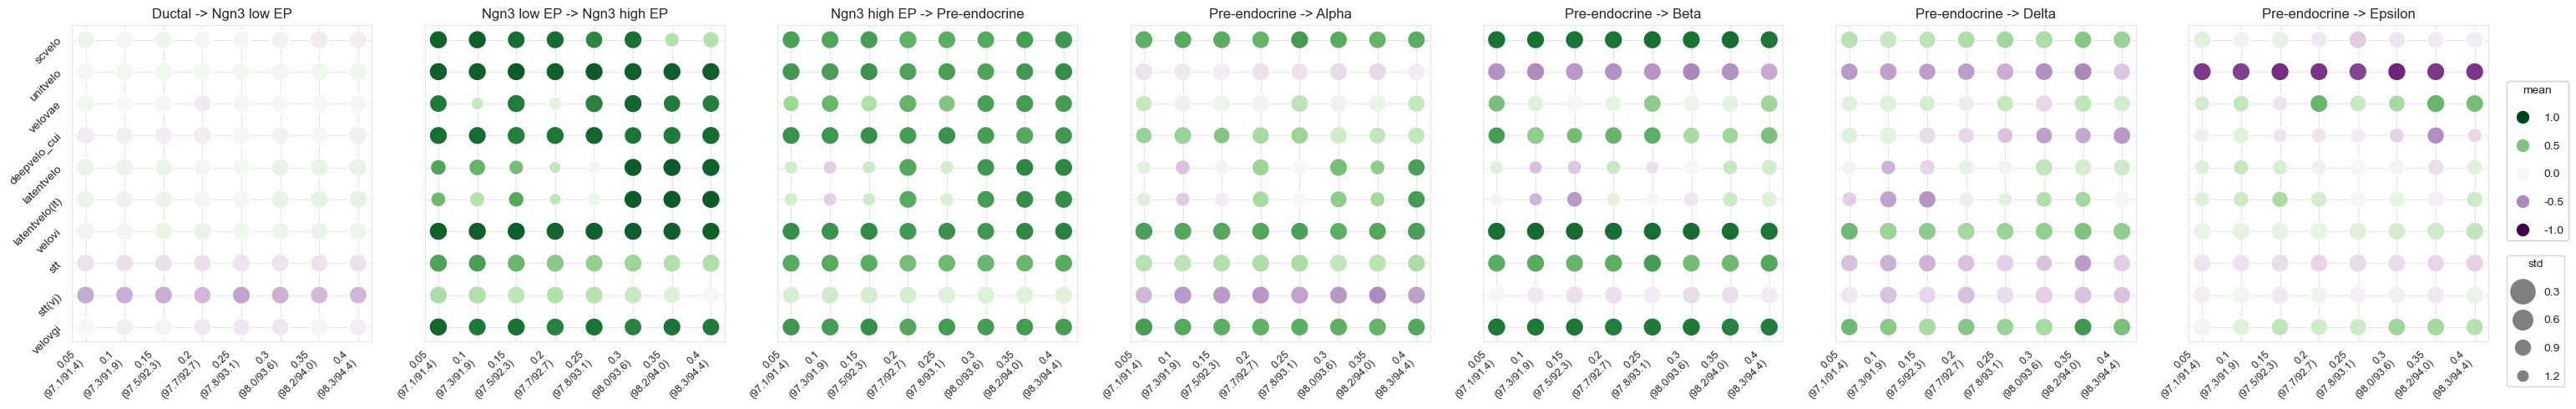

In [21]:
fig, axes = plt.subplots(1, len(results), figsize=(30, 5), sharex=True, sharey=True)
if len(results) == 1: axes = [axes]

for i, (edge, df_source) in enumerate(results.items()):
    ax = axes[i]
    
    # === 关键修复步骤 ===
    # 你的 df_source (即 results[edge]) 是 MultiIndex。
    # 我们创建一个临时的 df_plot，将 index 还原为列。
    df_plot = df_source.reset_index() 
    # 现在 df_plot 包含列: 'model', 'rate', 'mean', 'std', 'size'
    
    # 绘制散点图 (注意 data=df_plot)
    sns.scatterplot(
        data=df_plot, 
        x='rate',
        y='model',
        hue='mean',
        size='size',
        palette='PRGn',
        hue_norm=(-1, 1),
        size_norm=(0, 1.5),
        sizes=(50, 250),
        ax=ax,
    )
    
    ax.set_title(f"{edge}")
    ax.set_xlabel('')
    ax.set_ylabel('')

    # === 修改横坐标标签 ===
    # 1. 获取当前所有的 rate (因为 reset_index 了，所以现在可以是列)
    current_rates = sorted(df_plot['rate'].unique())
    
    # 2. 设置刻度位置
    ax.set_xticks(current_rates)
    
    # 3. 生成新标签 (从字典映射，如果没有找到则显示原始值)
    # 这里的 key 使用 round(r, 2) 以匹配之前生成的字典
    new_labels = [rate_label_map.get(round(r, 2), f"{r:.2f}") for r in current_rates]
    
    # 4. 应用新标签
    ax.set_xticklabels(new_labels)
    
    # 设置标签样式
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
        # 如果标签包含换行符，可能需要调整字体大小
        label.set_fontsize(9) 

    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
        
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# -----------------------------------------------------------
# 3. 图例部分 (保持不变)
# -----------------------------------------------------------
from matplotlib.lines import Line2D
mean_values = [1, 0.5, 0, -0.5, -1]
colors = plt.cm.PRGn(plt.Normalize(-1, 1)(mean_values))
mean_markers = [Line2D([0], [0], marker='o', color=colors[k], markerfacecolor=colors[k], markersize=10, linestyle='', label=f"{val:.1f}") for k, val in enumerate(mean_values)]

std_values = [0.3, 0.6, 0.9, 1.2]
original_sizes = [1.5 - std for std in std_values]
size_min, size_max = 50, 250
sizes = [size_min + (size_max - size_min) * (val / 1.5) for val in original_sizes]
size_markers = [Line2D([0], [0], marker='o', color='gray', markerfacecolor='gray', markersize=size/10, linestyle='', label=f"{std:.1f}") for size, std in zip(sizes, std_values)]

legend1 = fig.legend(handles=mean_markers, loc='lower left', bbox_to_anchor=(1, 0.4), ncol=1, frameon=True, title='mean', labelspacing=1.5)
fig.add_artist(legend1)

legend2 = fig.legend(handles=size_markers, loc='lower left', bbox_to_anchor=(1, 0.05), ncol=1, frameon=True, title='std', labelspacing=1.5)

plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.pdf', bbox_inches='tight')
plt.show()

In [18]:
save_dir

'/HDD1/xueweizhi/velocity_benchmark_data/pancreas/0.40'